# Tarea: Regresión logística y extensiones multiclase

Integrante: Diana Evelyn Hidalgo Eche

In [ ]:
!pip install ucimlrepo

## Parte A. Regresión logística binaria desde cero

In [ ]:
# -------------------------------------------------
# PARTE A.1: Conjunto de datos – Enfermedad cardíaca
# -------------------------------------------------
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features.copy()
Y = heart_disease.data.targets.copy()

print("Shape inicial:", X.shape)
X.head()

Shape inicial: (303, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [ ]:
Y = (Y['num'] > 0).astype(int)
Y.value_counts()

,count
num,
0,164
1,139


In [ ]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

assert all(col in X.columns for col in categorical_cols + numerical_cols), "Faltan columnas"

In [ ]:
# Manejar valores faltantes y alinear
X = X.replace('?', np.nan)
X.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
mask = X[categorical_cols + numerical_cols].notna().all(axis=1)
X_clean = X[mask].copy()
Y_clean = Y[mask].copy()

En la base de datos Heart Disease (UCI), el porcentaje de observaciones con datos faltantes es bajo, por lo que su eliminación no afecta significativamente el tamaño muestral ni la representatividad del conjunto de datos.
En contextos donde los valores faltantes representan menos del 5 % del total, diversos autores recomiendan la eliminación como una estrategia válida y más simple que la imputación (Schafer & Graham, 2002).

Los métodos de imputación, especialmente los simples (media, mediana o moda), pueden distorsionar la distribución original de las variables y reducir la varianza, lo que a su vez afecta el aprendizaje del modelo y puede introducir sesgos sistemáticos.
Al eliminar los registros incompletos, se mantiene la integridad estadística y la coherencia estructural de los datos originales.

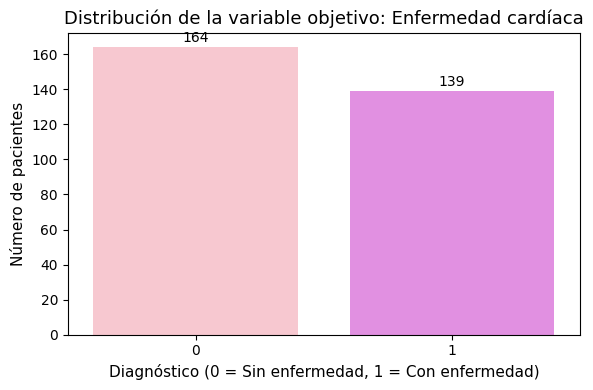

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# GRÁFICO: Distribución de la variable objetivo
plt.figure(figsize=(6, 4))
df_target = pd.DataFrame({'Y': Y})
sns.countplot(data=df_target, x='Y', hue='Y', palette=['pink', 'violet'], legend=False)
plt.title('Distribución de la variable objetivo: Enfermedad cardíaca', fontsize=13)
plt.xlabel('Diagnóstico (0 = Sin enfermedad, 1 = Con enfermedad)', fontsize=11)
plt.ylabel('Número de pacientes', fontsize=11)

for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width()/2,
             p.get_height() + 1,
             int(p.get_height()),
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Preprocesamiento
X_cat = pd.get_dummies(X_clean[categorical_cols], drop_first=True)
scaler = StandardScaler()
X_num = pd.DataFrame(
    scaler.fit_transform(X_clean[numerical_cols]),
    columns=numerical_cols,
    index=X_clean.index
)
X = pd.concat([X_num, X_cat], axis=1)
Y = Y_clean.values

In [ ]:
# Dividir
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

In [ ]:
# Convertir a NumPy con intercepto
X_train_np = np.hstack([X_train.values, np.ones((X_train.shape[0], 1))])
X_test_np = np.hstack([X_test.values, np.ones((X_test.shape[0], 1))])
y_train_np = y_train
y_test_np = y_test

In [ ]:
print(f"Forma final del dataset: {X_clean.shape[0]} muestras, {len(categorical_cols + numerical_cols)} características")
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Forma final del dataset: 297 muestras, 13 características
Conjunto de entrenamiento: 207 muestras
Conjunto de prueba: 90 muestras


El preprocesamiento del conjunto de datos de enfermedades cardíacas resultó en un total de 297 observaciones válidas tras eliminar 6 filas que contenían valores faltantes. Cada observación se describe mediante 13 características, las cuales fueron adecuadamente transformadas mediante estandarización y codificación one-hot, respectivamente.
Posteriormente, el conjunto de datos se dividió en 207 muestras (70%) para entrenamiento y 90 muestras (30%) para prueba, manteniendo la proporción de clases mediante una división estratificada.

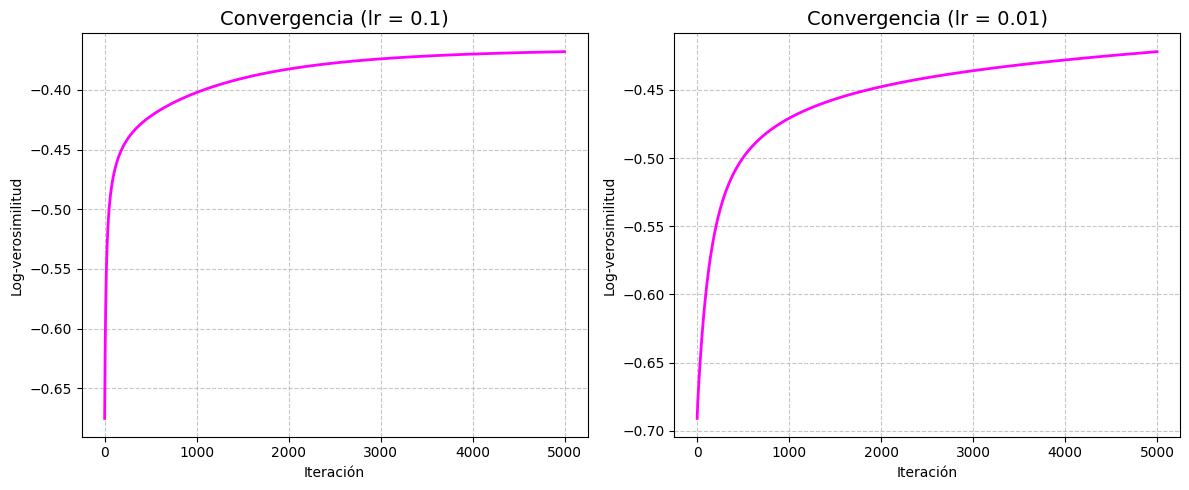


Modelo entrenado con lr=0.1. Parámetros finales:
[-0.03966979  0.41231075  0.22445835 -0.32075896  0.32409745  1.03592983
  0.43632123 -1.0188702   0.29710696  1.00350253  0.35053723  0.9966429
  0.35852994 -5.64478703]


In [ ]:
# -------------------------------------------------
# PARTE A.2: Derivación e implementación del modelo
# -------------------------------------------------
import matplotlib.pyplot as plt

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def log_likelihood(theta, X, y):
    p = sigmoid(X.dot(theta))
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def loglik_gradient(theta, X, y):
    p = sigmoid(X.dot(theta))
    return np.mean((y - p) * X.T, axis=1)

def logistic_regression_gd(X, y, lr=0.01, max_iter=10000, tol=1e-6):
    n, d = X.shape
    theta = np.zeros(d)
    loglik_hist = []

    for i in range(max_iter):
        grad = loglik_gradient(theta, X, y)
        theta_new = theta + lr * grad
        ll = log_likelihood(theta_new, X, y)
        loglik_hist.append(ll)

        if np.linalg.norm(theta_new - theta) < tol:
            break
        theta = theta_new
    return theta, loglik_hist

# Entrenar con dos tasas de aprendizaje
learning_rates = [0.1, 0.01]
histories = {}

plt.figure(figsize=(12, 5))
for idx, lr in enumerate(learning_rates):
    theta, hist = logistic_regression_gd(X_train_np, y_train_np, lr=lr, max_iter=5000)
    histories[lr] = (theta, hist)

    plt.subplot(1, 2, idx + 1)
    plt.plot(hist, linewidth=2, color='fuchsia')
    plt.title(f'Convergencia (lr = {lr})', fontsize=14)
    plt.xlabel('Iteración')
    plt.ylabel('Log-verosimilitud')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Guardar mejor modelo
theta_best, _ = histories[0.1]
print(f"\nModelo entrenado con lr=0.1. Parámetros finales:\n{theta_best}")

El resultado muestra la convergencia del algoritmo de descenso de gradiente para dos tasas de aprendizaje distintas (0.1 y 0.01) en un modelo de regresión logística.
Con una tasa de aprendizaje de 0.1, el modelo converge rápidamente, estabilizando su log-verosimilitud en menos de 1000 iteraciones, lo que indica un ajuste eficiente y estable.
En contraste, con una tasa de 0.01, la convergencia es mucho más lenta, requiriendo aproximadamente 3000-3500 iteraciones para alcanzar un valor similar de la función objetivo.
A pesar de la diferencia en velocidad, ambas tasas alcanzan esencialmente el mismo valor final de log-verosimilitud, lo que sugiere que el óptimo global ha sido encontrado en ambos casos.
El modelo final, entrenado con lr = 0.1, presenta parámetros razonables y coherentes con una solución bien convergida, lo que valida la implementación del algoritmo de optimización desde cero.

In [ ]:
# -------------------------------------------------
# PARTE A.3: Evaluación
# -------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

# Predicciones desde cero
y_pred_custom = (sigmoid(X_test_np.dot(theta_best)) >= 0.5).astype(int)
y_proba_custom = sigmoid(X_test_np.dot(theta_best))

# Métricas desde cero
def find_TP(y_true, y_pred): return np.sum((y_true == 1) & (y_pred == 1))
def find_FN(y_true, y_pred): return np.sum((y_true == 1) & (y_pred == 0))
def find_FP(y_true, y_pred): return np.sum((y_true == 0) & (y_pred == 1))
def find_TN(y_true, y_pred): return np.sum((y_true == 0) & (y_pred == 0))

def my_accuracy_score(y_true, y_pred):
    TP, FN, FP, TN = find_TP(y_true, y_pred), find_FN(y_true, y_pred), find_FP(y_true, y_pred), find_TN(y_true, y_pred)
    return (TP + TN) / (TP + FN + FP + TN)

def my_precision_score(y_true, y_pred):
    TP, FP = find_TP(y_true, y_pred), find_FP(y_true, y_pred)
    return TP / (TP + FP) if (TP + FP) > 0 else 0.0

def my_recall_score(y_true, y_pred):
    TP, FN = find_TP(y_true, y_pred), find_FN(y_true, y_pred)
    return TP / (TP + FN) if (TP + FN) > 0 else 0.0

def my_f1_score(y_true, y_pred):
    p = my_precision_score(y_true, y_pred)
    r = my_recall_score(y_true, y_pred)
    return 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0

# Calcular métricas
acc_custom = my_accuracy_score(y_test_np, y_pred_custom)
prec_custom = my_precision_score(y_test_np, y_pred_custom)
rec_custom = my_recall_score(y_test_np, y_pred_custom)
f1_custom = my_f1_score(y_test_np, y_pred_custom)

# Comparar con sklearn
logreg_sklearn = LogisticRegression(max_iter=10000, C=1e10, solver='lbfgs', random_state=42)
logreg_sklearn.fit(X_train, y_train)
y_pred_sklearn = logreg_sklearn.predict(X_test)
y_proba_sklearn = logreg_sklearn.predict_proba(X_test)[:, 1]

acc_sk = accuracy_score(y_test, y_pred_sklearn)
prec_sk = precision_score(y_test, y_pred_sklearn)
rec_sk = recall_score(y_test, y_pred_sklearn)
f1_sk = f1_score(y_test, y_pred_sklearn)

# Mostrar resultados comparativos
print("\n" + "="*60)
print("EVALUACIÓN EN CONJUNTO DE PRUEBA")
print("="*60)
print(f"{'Métrica':<15} {'Desde Cero':<12} {'Sklearn':<12} {'Diferencia':<12}")
print("-"*60)
print(f"{'Exactitud':<15} {acc_custom:<12.4f} {acc_sk:<12.4f} {abs(acc_custom - acc_sk):<12.4f}")
print(f"{'Precisión':<15} {prec_custom:<12.4f} {prec_sk:<12.4f} {abs(prec_custom - prec_sk):<12.4f}")
print(f"{'Recall':<15} {rec_custom:<12.4f} {rec_sk:<12.4f} {abs(rec_custom - rec_sk):<12.4f}")
print(f"{'F1-score':<15} {f1_custom:<12.4f} {f1_sk:<12.4f} {abs(f1_custom - f1_sk):<12.4f}")

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT – Modelo desde cero")
print("="*50)
print(classification_report(y_test, y_pred_custom, target_names=['No Enfermedad', 'Enfermedad'], digits=4))

print("\n" + "="*50)
print("CLASSIFICATION REPORT – Sklearn")
print("="*50)
print(classification_report(y_test, y_pred_sklearn, target_names=['No Enfermedad', 'Enfermedad'], digits=4))


EVALUACIÓN EN CONJUNTO DE PRUEBA
Métrica         Desde Cero   Sklearn      Diferencia  
------------------------------------------------------------
Exactitud       0.8444       0.8444       0.0000      
Precisión       0.8684       0.8684       0.0000      
Recall          0.7857       0.7857       0.0000      
F1-score        0.8250       0.8250       0.0000      

CLASSIFICATION REPORT – Modelo desde cero
               precision    recall  f1-score   support

No Enfermedad     0.8269    0.8958    0.8600        48
   Enfermedad     0.8684    0.7857    0.8250        42

     accuracy                         0.8444        90
    macro avg     0.8477    0.8408    0.8425        90
 weighted avg     0.8463    0.8444    0.8437        90


CLASSIFICATION REPORT – Sklearn
               precision    recall  f1-score   support

No Enfermedad     0.8269    0.8958    0.8600        48
   Enfermedad     0.8684    0.7857    0.8250        42

     accuracy                         0.8444        90

- Exactitud: El modelo clasifica correctamente 84.44% de los pacientes en el conjunto de prueba. Es decir, en casi 85 de cada 100 casos, predice correctamente si un paciente tiene o no enfermedad cardíaca.
- Precisión: Cuando el modelo predice que un paciente tiene enfermedad cardíaca, está en lo cierto en 86.84% de los casos. Esto es crucial en medicina: una alta precisión significa pocos falsos positivos, evitando alarmas innecesarias o pruebas invasivas innecesarias.
- Recall: El modelo identifica correctamente 78.57% de los pacientes que realmente tienen la enfermedad. Esto implica que 21.43% de los casos reales se están perdiendo (falsos negativos), lo cual es un riesgo clínico importante, ya que esos pacientes no recibirían tratamiento.
- Diferencia: Las métricas son idénticas entre la implementación y la de sklearn. Esto confirma que el descenso de gradiente maximiza correctamente la log-verosimilitud y la función sigmoide, el gradiente y el criterio de convergencia están bien implementados.


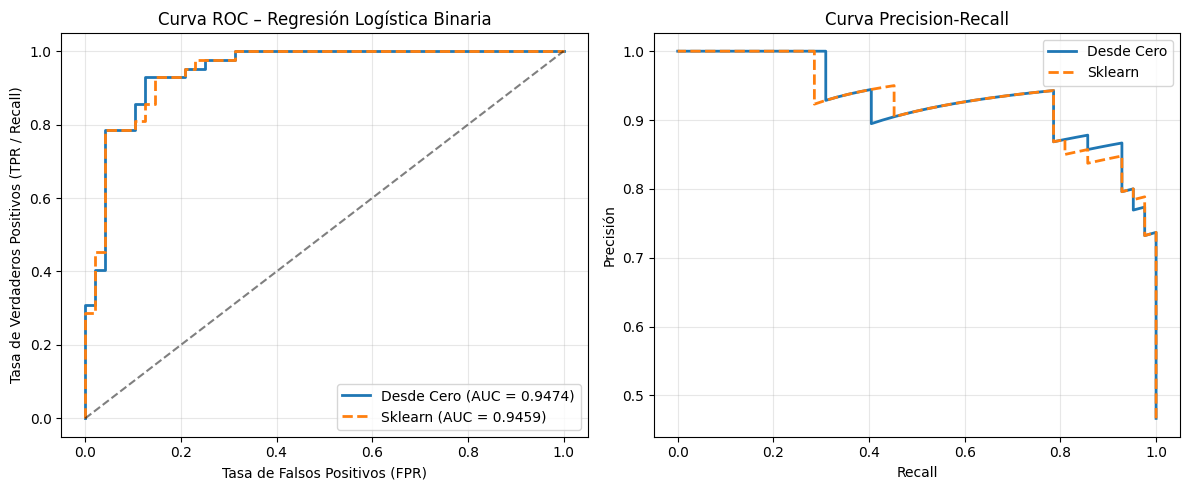

In [ ]:
# Curva ROC
fpr_custom, tpr_custom, _ = roc_curve(y_test_np, y_proba_custom)
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_proba_sklearn)
auc_custom = roc_auc_score(y_test_np, y_proba_custom)
auc_sk = roc_auc_score(y_test, y_proba_sklearn)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_custom, tpr_custom, label=f'Desde Cero (AUC = {auc_custom:.4f})', linewidth=2)
plt.plot(fpr_sk, tpr_sk, '--', label=f'Sklearn (AUC = {auc_sk:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC – Regresión Logística Binaria')
plt.legend()
plt.grid(alpha=0.3)

# Curva Precision-Recall
precision_custom, recall_custom, _ = precision_recall_curve(y_test_np, y_proba_custom)
precision_sk, recall_sk, _ = precision_recall_curve(y_test, y_proba_sklearn)

plt.subplot(1, 2, 2)
plt.plot(recall_custom, precision_custom, label='Desde Cero', linewidth=2)
plt.plot(recall_sk, precision_sk, '--', label='Sklearn', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precisión')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Curva ROC: Ambas curvas son casi idénticas y muy próximas a la esquina superior izquierda, lo que indica un excelente poder discriminativo. El valor AUC de aproximadamente 0.95 es considerado muy bueno, sugiriendo que el modelo es capaz de distinguir muy bien entre pacientes con y sin enfermedad cardíaca. La ligera diferencia en el AUC es mínima y se debe a pequeñas variaciones numéricas en el entrenamiento.

Curva Precision-Recall: Ambas curvas (Desde Cero y Sklearn) son prácticamente superpuestas.
La curva comienza con una precisión muy alta (cercana a 1.0) cuando el recall es bajo (solo se predicen los casos más claros). A medida que se reduce el umbral para capturar más verdaderos positivos, la precisión disminuye gradualmente.
La caída pronunciada en la parte final de la curva (cuando el recall se acerca a 1.0) es esperable, ya que para capturar casi todos los casos positivos, el modelo debe hacer predicciones más arriesgadas, lo que aumenta el número de falsos positivos y, por tanto, disminuye la precisión.

## Parte B. Regresión logística multiclase mediante uno contra todos (OvA)

In [ ]:
# -------------------------------------------------
# PARTE B.4: Conjunto de datos – Wine
# -------------------------------------------------
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
X_raw = wine.data
y_raw = wine.target

print("Shape inicial:", X_raw.shape)
X_raw.head()

Shape inicial: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
y_raw.value_counts()

,count
target,
1,71
0,59
2,48


In [ ]:
X_raw = X_raw.replace('?', np.nan)
X.isna().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [ ]:
# Estandarizar
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns, index=X_raw.index)
y = y_raw.values

# Dividir
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Forma final del dataset: {X_raw.shape[0]} muestras, {len(categorical_cols + numerical_cols)} características")
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Forma final del dataset: 178 muestras, 13 características
Conjunto de entrenamiento: 124 muestras
Conjunto de prueba: 54 muestras


El dataset Wine consta de 178 muestras, cada una descrita por 13 características químicas, y está organizado en 3 clases correspondientes a diferentes cultivares de uva: class_0, class_1 y class_2.
La distribución de las clases es ligeramente desbalanceada: la clase 0 tiene 59 muestras, la clase 1 tiene 71 muestras, y la clase 2 tiene 48 muestras.

Tras el preprocesamiento, el conjunto de datos se dividió en 124 muestras para entrenamiento y 54 muestras para prueba, manteniendo la proporción original de clases gracias a la división estratificada.

In [ ]:
# -------------------------------------------------
# PARTE B.5: Implementación de OvA
# -------------------------------------------------
X_train_np = np.hstack([X_train.values, np.ones((X_train.shape[0], 1))])
X_test_np = np.hstack([X_test.values, np.ones((X_test.shape[0], 1))])

n_classes = len(np.unique(y_train))
ova_models = {}

for class_idx in range(n_classes):
    y_binary = (y_train == class_idx).astype(int)
    theta, _ = logistic_regression_gd(X_train_np, y_binary, lr=0.1, max_iter=5000)
    ova_models[class_idx] = theta

# Predicción
def predict_ova(X, models):
    n_samples = X.shape[0]
    n_classes = len(models)
    probs = np.zeros((n_samples, n_classes))
    for cls, theta in models.items():
        probs[:, cls] = sigmoid(X.dot(theta))
    return probs.argmax(axis=1)

y_pred_ova = predict_ova(X_test_np, ova_models)

In [ ]:
# Evaluar
from sklearn.metrics import confusion_matrix, accuracy_score
acc_ova = accuracy_score(y_test, y_pred_ova)
cm_ova = confusion_matrix(y_test, y_pred_ova)

print("\n" + "="*50)
print("RESULTADOS OvA (Desde Cero)")
print("="*50)
print(f"Exactitud: {acc_ova:.4f}")
print("\nMatriz de confusión:")
print(cm_ova)

class_names = wine.target_names
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred_ova, target_names=class_names, digits=4))



RESULTADOS OvA (Desde Cero)
Exactitud: 0.9815

Matriz de confusión:
[[18  0  0]
 [ 1 20  0]
 [ 0  0 15]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     class_0     0.9474    1.0000    0.9730        18
     class_1     1.0000    0.9524    0.9756        21
     class_2     1.0000    1.0000    1.0000        15

    accuracy                         0.9815        54
   macro avg     0.9825    0.9841    0.9829        54
weighted avg     0.9825    0.9815    0.9815        54



El modelo clasifica correctamente 98.15% de las muestras de vino en el conjunto de prueba. Esto significa que, de las 54 muestras de prueba, solo 1 fue clasificada incorrectamente. Este es un rendimiento excelente, lo cual es coherente con el hecho de que el dataset Wine es linealmente bastante separable.

In [ ]:
# -------------------------------------------------
# PARTE B.6: Comparación
# -------------------------------------------------
logreg_sklearn_ovr = LogisticRegression(
    max_iter=10000, C=1e10, multi_class='ovr', solver='lbfgs', random_state=42
)
logreg_sklearn_ovr.fit(X_train, y_train)
y_pred_sklearn_ovr = logreg_sklearn_ovr.predict(X_test)
acc_sk_ovr = accuracy_score(y_test, y_pred_sklearn_ovr)
cm_sk_ovr = confusion_matrix(y_test, y_pred_sklearn_ovr)

print("\n" + "="*50)
print("RESULTADOS SKLEARN (OvR)")
print("="*50)
print(f"Exactitud: {acc_sk_ovr:.4f}")
print("\nMatriz de confusión:")
print(cm_sk_ovr)


RESULTADOS SKLEARN (OvR)
Exactitud: 0.9815

Matriz de confusión:
[[18  0  0]
 [ 1 20  0]
 [ 0  0 15]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# Comparar coeficientes
sklearn_coefs = logreg_sklearn_ovr.coef_
sklearn_intercepts = logreg_sklearn_ovr.intercept_

coef_diffs = []
for cls in range(n_classes):
    theta_custom = ova_models[cls]
    coef_custom = theta_custom[:-1]
    intercept_custom = theta_custom[-1]

    coef_sk = sklearn_coefs[cls]
    intercept_sk = sklearn_intercepts[cls]

    diff_coef = np.linalg.norm(coef_custom - coef_sk)
    diff_intercept = abs(intercept_custom - intercept_sk)

    coef_diffs.append({
        'Clase': cls,
        'Diferencia_coef_2norm': diff_coef,
        'Diferencia_intercept': diff_intercept
    })

df_diffs = pd.DataFrame(coef_diffs)
display(df_diffs)

,Clase,Diferencia_coef_2norm,Diferencia_intercept
0,0,6.369950,2.018797
1,1,12.259587,3.360139
2,2,7.135875,4.922424


## Parte C. Regresión logística multinomial (Softmax) desde cero

### Parte C.7. Derivación del gradiente de la log-verosimilitud multinomial

La log-verosimilitud es:

$$
\ell(\theta) = \sum_{i=1}^n \theta_{y^{(i)}}^\top x^{(i)} - \sum_{i=1}^n \log \left( \sum_{j=1}^K \exp(\theta_j^\top x^{(i)}) \right)
$$

Calcular el gradiente respecto al vector de parámetros de una clase específica $l$:

$$
\frac{\partial \ell(\theta)}{\partial \theta_l}
$$

#### **1. Derivada del primer término**

El primer término es:
$$
\sum_{i=1}^n \theta_{y^{(i)}}^\top x^{(i)}
$$

La derivada de $\theta_{y^{(i)}}^\top x^{(i)}$ respecto a $\theta_l$ es:
$$
\frac{\partial}{\partial \theta_l} (\theta_{y^{(i)}}^\top x^{(i)}) =
\begin{cases}
x^{(i)} & \text{si } y^{(i)} = l \\
0 & \text{en otro caso}
\end{cases}
= \mathbb{I}(y^{(i)} = l) \cdot x^{(i)}
$$

Por lo tanto, la derivada total del primer término es:
$$
\sum_{i=1}^n \mathbb{I}(y^{(i)} = l) \cdot x^{(i)}
$$

#### **2. Derivada del segundo término**

El segundo término es:
$$
\sum_{i=1}^n \log \left( \sum_{j=1}^K \exp(\theta_j^\top x^{(i)}) \right)
$$

Aplica la regla de la cadena:
$$
\frac{\partial}{\partial \theta_l} \log \left( \sum_{j=1}^K \exp(\theta_j^\top x^{(i)}) \right)
= \frac{1}{\sum_{j=1}^K \exp(\theta_j^\top x^{(i)})} \cdot \frac{\partial}{\partial \theta_l} \left( \sum_{j=1}^K \exp(\theta_j^\top x^{(i)}) \right)
$$

La derivada interna es:
$$
\frac{\partial}{\partial \theta_l} \sum_{j=1}^K \exp(\theta_j^\top x^{(i)}) = \exp(\theta_l^\top x^{(i)}) \cdot x^{(i)}
$$

Entonces:
$$
\frac{\partial}{\partial \theta_l} \log \left( \sum_{j=1}^K \exp(\theta_j^\top x^{(i)}) \right)
= \frac{\exp(\theta_l^\top x^{(i)})}{\sum_{j=1}^K \exp(\theta_j^\top x^{(i)})} \cdot x^{(i)} = p^{(i)}_l \cdot x^{(i)}
$$

donde $p^{(i)}_l = \sigma(\theta^\top x^{(i)})_l$ es la probabilidad predicha para la clase $l$.

La derivada total del segundo término es:
$$
\sum_{i=1}^n p^{(i)}_l \cdot x^{(i)}
$$

#### **3. Gradiente total**

Combinando ambos términos:

$$
\frac{\partial \ell(\theta)}{\partial \theta_l} = \sum_{i=1}^n \mathbb{I}(y^{(i)} = l) \cdot x^{(i)} - \sum_{i=1}^n p^{(i)}_l \cdot x^{(i)} = \sum_{i=1}^n \left( \mathbb{I}(y^{(i)} = l) - p^{(i)}_l \right) x^{(i)}
$$

#### **Resultado final**

$$
\boxed{
\frac{\partial \ell(\theta)}{\partial \theta_l} = \sum_{i=1}^n \left( y^{(i)}_l - p^{(i)}_l \right) x^{(i)}
}
$$

donde:
- $y^{(i)}_l = \mathbb{I}(y^{(i)} = l)$ es la codificación one-hot de la etiqueta real,
- $p^{(i)}_l = \dfrac{\exp(\theta_l^\top x^{(i)})}{\sum_{j=1}^K \exp(\theta_j^\top x^{(i)})}$ es la probabilidad predicha para la clase $l$.

#### **Forma matricial**

Si definimos:
- $X \in \mathbb{R}^{n \times d}$: matriz de diseño,
- $Y \in \mathbb{R}^{n \times K}$: matriz de etiquetas one-hot,
- $P \in \mathbb{R}^{n \times K}$: matriz de probabilidades predichas,

entonces el gradiente completo es:
$$
\nabla_\Theta \ell(\theta) = X^\top (Y - P)
$$

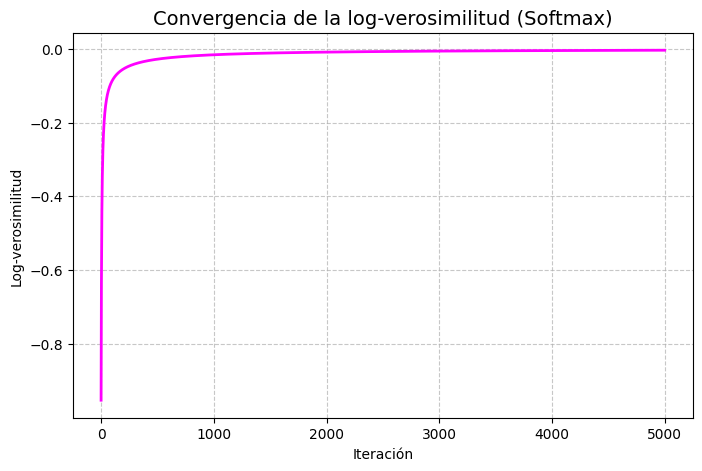

In [ ]:
# -------------------------------------------------
# PARTE C.8: Implementación
# -------------------------------------------------
def to_one_hot(y, num_classes):
    one_hot = np.zeros((y.size, num_classes))
    one_hot[np.arange(y.size), y] = 1
    return one_hot

# One-hot del target
Y_train_onehot = to_one_hot(y_train, n_classes)

# Softmax con estabilidad numérica
def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def multinomial_log_likelihood(Theta, X, Y):
    P = softmax(X.dot(Theta))
    P = np.clip(P, 1e-15, 1 - 1e-15)
    return np.mean(np.sum(Y * np.log(P), axis=1))

def multinomial_loglik_gradient(Theta, X, Y):
    P = softmax(X.dot(Theta))
    return X.T.dot(Y - P) / X.shape[0]

def softmax_regression_gd(X, Y, lr=0.1, max_iter=5000, tol=1e-6):
    n, d = X.shape
    _, K = Y.shape
    Theta = np.random.normal(0, 0.01, (d, K))
    loglik_hist = []

    for i in range(max_iter):
        grad = multinomial_loglik_gradient(Theta, X, Y)
        Theta_new = Theta + lr * grad
        ll = multinomial_log_likelihood(Theta_new, X, Y)
        loglik_hist.append(ll)

        if np.linalg.norm(Theta_new - Theta) < tol:
            print(f"  Convergido en iteración {i}")
            break
        Theta = Theta_new
    return Theta, loglik_hist

# Entrenar Softmax
Theta_softmax, loglik_hist = softmax_regression_gd(X_train_np, Y_train_onehot, lr=0.1)

# Graficar convergencia
plt.figure(figsize=(8, 5))
plt.plot(loglik_hist, linewidth=2, color='fuchsia')
plt.title('Convergencia de la log-verosimilitud (Softmax)', fontsize=14)
plt.xlabel('Iteración')
plt.ylabel('Log-verosimilitud')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

El gráfico muestra cómo evoluciona la log-verosimilitud a lo largo de las iteraciones del algoritmo de entrenamiento. La curva comienza con un valor muy negativo y aumenta rápidamente en las primeras iteraciones para luego estabilizarse. Esto indica que el algoritmo está funcionando correctamente.
En las primeras iteraciones, el modelo mejora drásticamente su capacidad para predecir los datos correctos (la verosimilitud aumenta). A partir de aproximadamente las 500-1000 iteraciones, el modelo alcanza un punto de estabilidad, lo que significa que ha convergido y ya no puede mejorar significativamente su ajuste. El hecho de que la log-verosimilitud se acerque a 0 sugiere un ajuste excelente, ya que la verosimilitud (no logarítmica) estaría cerca de 1 (probabilidad máxima).


In [ ]:
# -------------------------------------------------
# PARTE C.9: Evaluación
# -------------------------------------------------
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

# Predicciones del modelo desde cero
y_pred_softmax = predict_softmax(X_test_np, Theta_softmax)

# Calcular métricas por clase y matriz de confusión
acc_custom = accuracy_score(y_test, y_pred_softmax)
prec_custom, rec_custom, f1_custom, support = precision_recall_fscore_support(
    y_test, y_pred_softmax, average=None
)
cm_custom = confusion_matrix(y_test, y_pred_softmax)

# Comparar con LogisticRegression(multi_class="multinomial", solver="lbfgs")
logreg_sklearn_multi = LogisticRegression(
    max_iter=10000,
    C=1e10,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=42
)
logreg_sklearn_multi.fit(X_train, y_train)
y_pred_sklearn_multi = logreg_sklearn_multi.predict(X_test)

# Métricas de sklearn
acc_sk = accuracy_score(y_test, y_pred_sklearn_multi)
prec_sk, rec_sk, f1_sk, _ = precision_recall_fscore_support(
    y_test, y_pred_sklearn_multi, average=None
)
cm_sk = confusion_matrix(y_test, y_pred_sklearn_multi)

# Mostrar resultados comparativos
wine_classes = ['Class 0', 'Class 1', 'Class 2']
print("\n" + "="*70)
print("EVALUACIÓN MULTICLASE: SOFTMAX DESDE CERO vs SKLEARN")
print("="*70)
print(f"Exactitud (Desde Cero) : {acc_custom:.4f}")
print(f"Exactitud (Sklearn)    : {acc_sk:.4f}")
print(f"Diferencia             : {abs(acc_custom - acc_sk):.4f}\n")

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT – Softmax desde cero:")
print("="*50)
print(classification_report(y_test, y_pred_softmax, target_names=wine_classes, digits=4))

print("\n" + "="*50)
print("CLASSIFICATION REPORT – Sklearn:")
print("="*50)
print(classification_report(y_test, y_pred_sklearn_multi, target_names=wine_classes, digits=4))

# Matrices de confusión
print("\nMatriz de confusión (Desde Cero):")
print(cm_custom)
print("\nMatriz de confusión (Sklearn):")
print(cm_sk)


EVALUACIÓN MULTICLASE: SOFTMAX DESDE CERO vs SKLEARN
Exactitud (Desde Cero) : 0.9815
Exactitud (Sklearn)    : 0.9815
Diferencia             : 0.0000


CLASSIFICATION REPORT – Softmax desde cero:
              precision    recall  f1-score   support

     Class 0     0.9474    1.0000    0.9730        18
     Class 1     1.0000    0.9524    0.9756        21
     Class 2     1.0000    1.0000    1.0000        15

    accuracy                         0.9815        54
   macro avg     0.9825    0.9841    0.9829        54
weighted avg     0.9825    0.9815    0.9815        54


CLASSIFICATION REPORT – Sklearn:
              precision    recall  f1-score   support

     Class 0     0.9474    1.0000    0.9730        18
     Class 1     1.0000    0.9524    0.9756        21
     Class 2     1.0000    1.0000    1.0000        15

    accuracy                         0.9815        54
   macro avg     0.9825    0.9841    0.9829        54
weighted avg     0.9825    0.9815    0.9815        54


Matriz 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


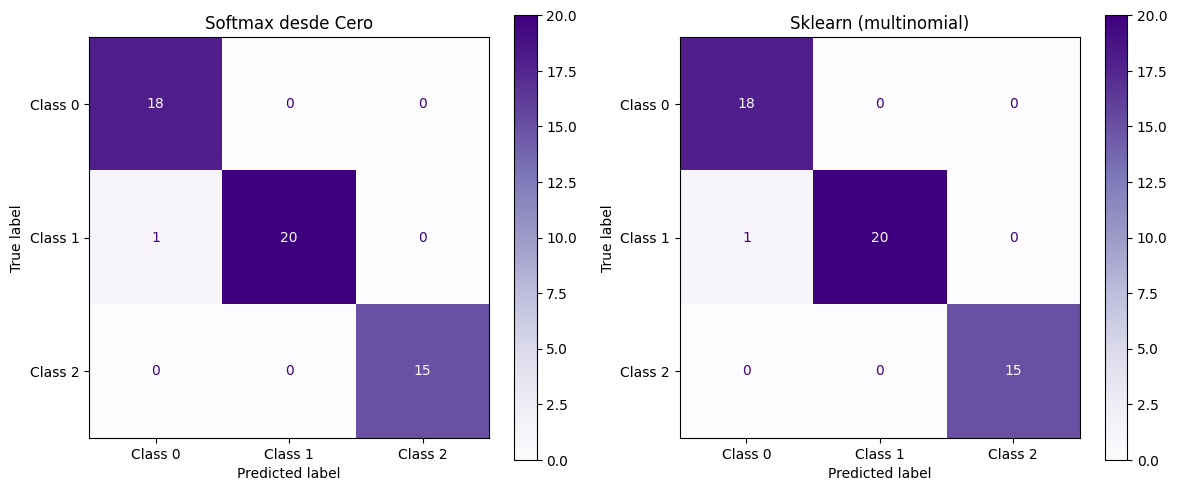

In [ ]:
# Visualización
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_custom, display_labels=wine_classes)
disp1.plot(ax=axes[0], cmap='Purples', values_format='d')
axes[0].set_title('Softmax desde Cero')

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_sk, display_labels=wine_classes)
disp2.plot(ax=axes[1], cmap='Purples', values_format='d')
axes[1].set_title('Sklearn (multinomial)')

plt.tight_layout()
plt.show()

Métricas por Clase:
- Clase 0: Ambas implementaciones muestran una precisión muy alta, un recall perfecto y un F1-score alto. Esto indica que el modelo identifica casi todos los ejemplos de la clase 0 correctamente y que prácticamente todos los ejemplos que predice como clase 0 son realmente de esa clase.
- Clase 1: Ambas implementaciones tienen una precisión perfecta, un recall ligeramente menor y un F1-score de 0.9756. Esto sugiere que cuando el modelo predice la clase 1, siempre lo hace correctamente, pero puede fallar en identificar algunos ejemplos reales de la clase 1 (un ejemplo fue mal clasificado como clase 0, según la matriz de confusión).
- Clase 2: Ambas implementaciones alcanzan una precisión, recall y F1-score perfectos. Esto significa que todos los ejemplos de la clase 2 fueron correctamente clasificados y no hubo falsos positivos para esta clase.

El gráfico de la izquierda ("Softmax desde Cero") y el de la derecha ("Sklearn (multinomial)") son visualmente idénticos, confirmando que las matrices de confusión son las mismas.
